##### 📂 **Purpose of This Notebook**  <small>
This notebook visualizes events from the sample dataset. Each plot includes **acceleration** and **heart rate** signals, with expertly annotated class labels displayed along the upper x-axis. Plots are saved as PNG images in the folder: **`_Sample_Event_Labels`**.  

##### 📂 **Ground Truth Labels and Colors:**  
   - ⚪ Normal (0): White  
   - 🔵 *Pre-Ictal (1): Blue  
   - 🟢 Ictal (2): Green  
---

##### 📂 **Code Explanation**  
Events are grouped by **`eventId`** and plotted using Matplotlib. Events are constructed from multiple timesteps, where each timestep consists of 125 datapoints per feature and represents a 5-second window. Plots are detailed as follows:
   - 🕒 **Time** on the **lower x-axis** (Constructed from 5-second timesteps).  
   - 🖋️ **Expertly Annotated Class Labels** on the **upper x-axis**.  
   - 📈 **Acceleration (`rawData`)** on the **primary y-axis**.  
   - ❤️ **Heart Rate (`ppg`)** on the **secondary y-axis**.  

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import os
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", message=".*set_ticklabels.*")

# Reading data from Google Drive
sample_dataset_path = '../Data/sample_dataset.csv'
df = pd.read_csv(sample_dataset_path)


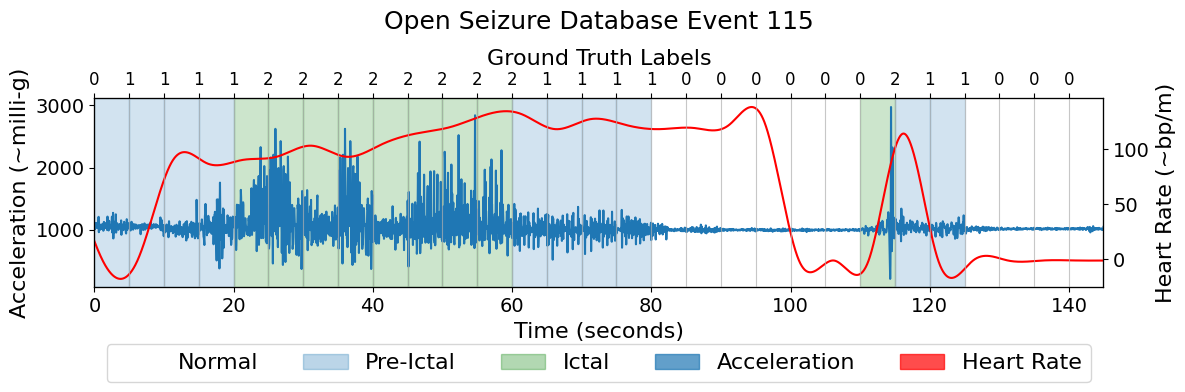

KeyboardInterrupt: 

In [4]:
# Define colors for each class label
label_colors = {
    0: "white",     # Normal
    1: "tab:blue",  # Pre-Ictal
    2: "green"      # Ictal
}

# Plot each eventId
for event_id, event_data in df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Add the labels on the upper x-axis (ax3) with a static 0 at the beginning
    ax3 = ax1.twiny()
    
    # Directly use the adjusted labels for ax3 ticks and labels
    ax3.set_xticklabels(adjusted_labels, fontsize=12)  # Use the adjusted labels directly
    ax3.set_xticks(adjusted_label_positions)  # Set the positions of the x-ticks
    ax3.set_xlabel("Ground Truth Labels", fontsize=16)
    ax3.tick_params(axis='x', labelsize=12)
    ax3.grid(axis='x', linestyle='-', linewidth=0.8, alpha=0.7)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax3.set_xlim(0, time_axis[-1])

    # Add background colors for each class label based on label values (0, 1, 2)
    for i in range(len(labels)):
        start = label_positions[i]   # Shift background start by 5 seconds
        end = label_positions[i + 1] if i + 1 < len(labels) else time_axis[-1]  # Shift background end by 5 seconds
        color = label_colors.get(labels[i], "white")
        ax1.axvspan(start, end, color=color, alpha=0.2)  # Background color on ax1 (rawData)

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id}", fontsize=18, pad=50)

    # Add legends for background colors
    custom_legends = [
        mpatches.Patch(color="white", alpha=0.3, label="Normal"),
        mpatches.Patch(color="tab:blue", alpha=0.3, label="Pre-Ictal"),
        mpatches.Patch(color="green", alpha=0.3, label="Ictal"),
        mpatches.Patch(color="tab:blue", alpha=0.7, label="Acceleration"),
        mpatches.Patch(color="red", alpha=0.7, label="Heart Rate")
    ]
    
    ax1.legend(handles=custom_legends, loc='lower center', fontsize=16, frameon=True,
               ncol=5, bbox_to_anchor=(0.5, -0.5), borderaxespad=0)

    # Adjust layout for spacing
    fig.tight_layout()

    # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Event_Labels/event_{event_id}.png")

    # Show the plot
    plt.show()


##### 📂 **Visualizing Sample Events by Specific Epilepsy Subtype**
<small>

The next section of the notebook focuses on creating separate visualization plots for each epilepsy subtype (`Tonic-Clonic`, `Aura`, and `Other`). Each subtype is filtered from the dataset, and the raw data for each event is plotted.



---

##### 📂 **Subtype-Specific Visualization for Aura/Pre-Ictal Events**
<small>
This section focuses on visualizing and filtering events classified as `subType = 'Aura'. It provides insights into the temporal patterns of these events by plotting key features where: 

- **1️⃣ X-Axis**: Represents the time of the event in **5-second timesteps**.  
- **2️⃣ Y-Axis**: Displays the dataset's features:  
  - **📌 Acceleration** (`rawData`)  
  - **📌 Heart Rate** (`ppg`)  

The generated plots are automatically saved in the folder: **`Sample_Event_Types/Aura`**  

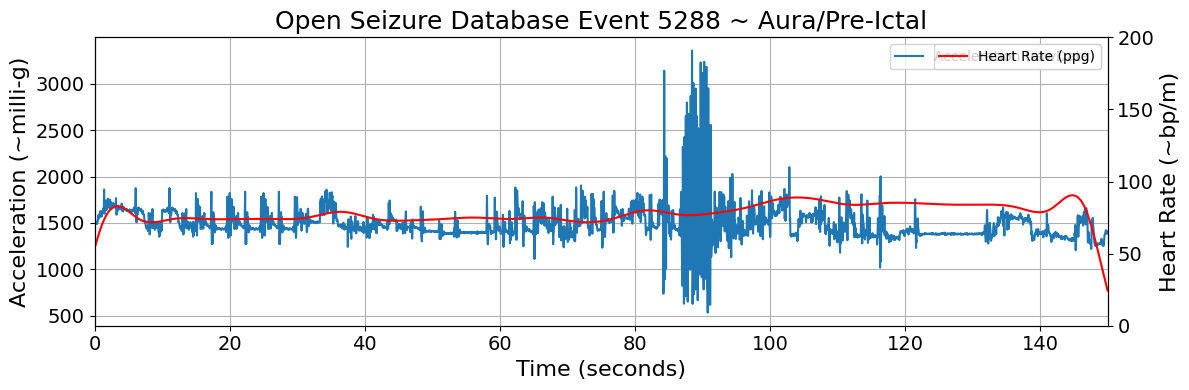

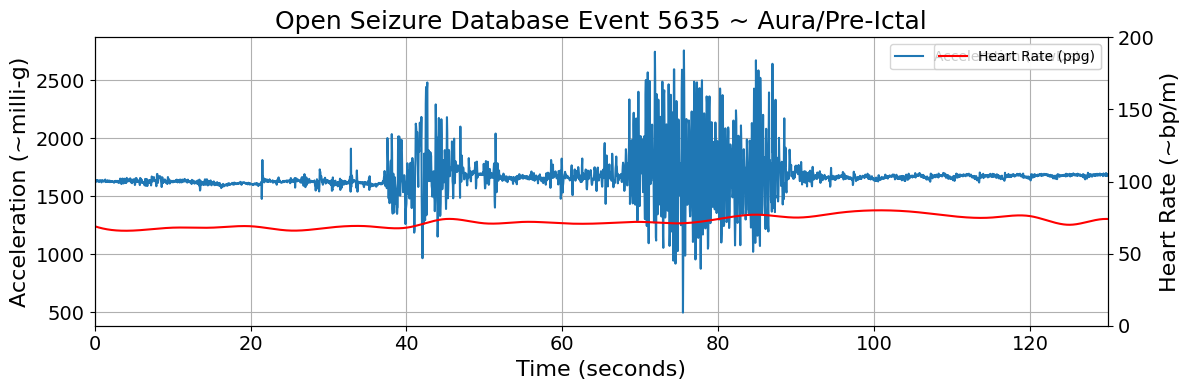

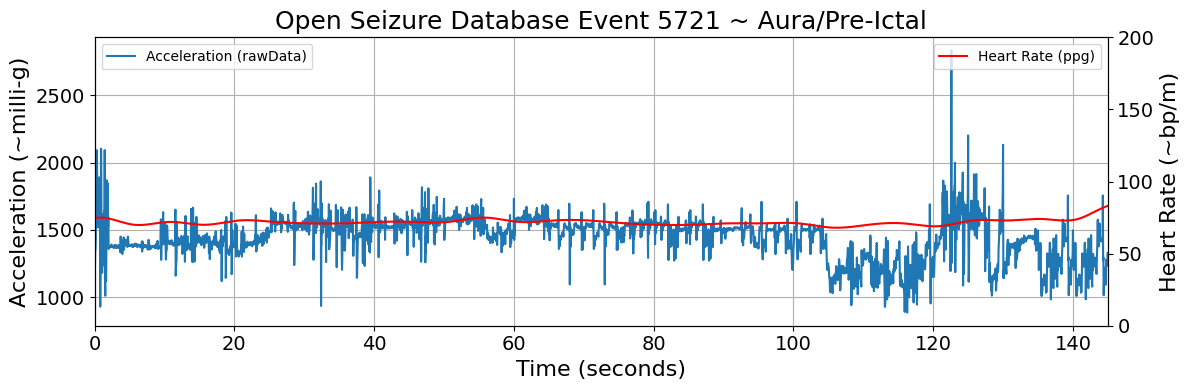

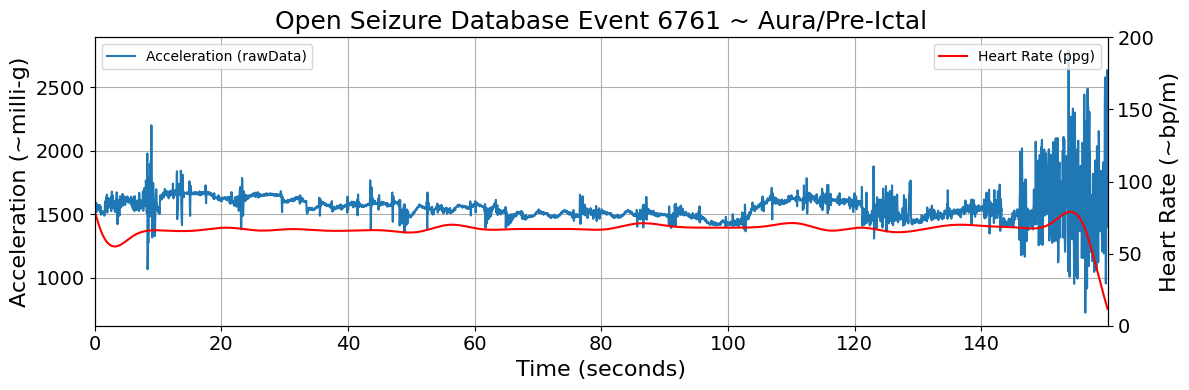

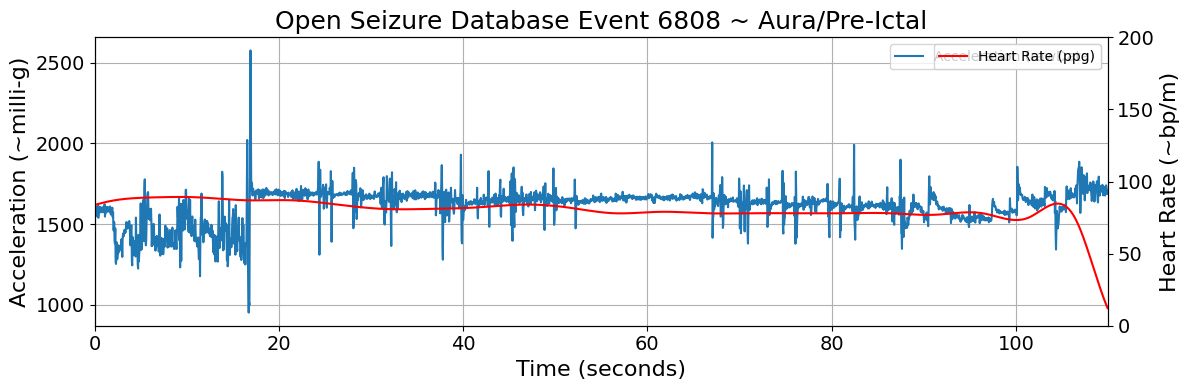

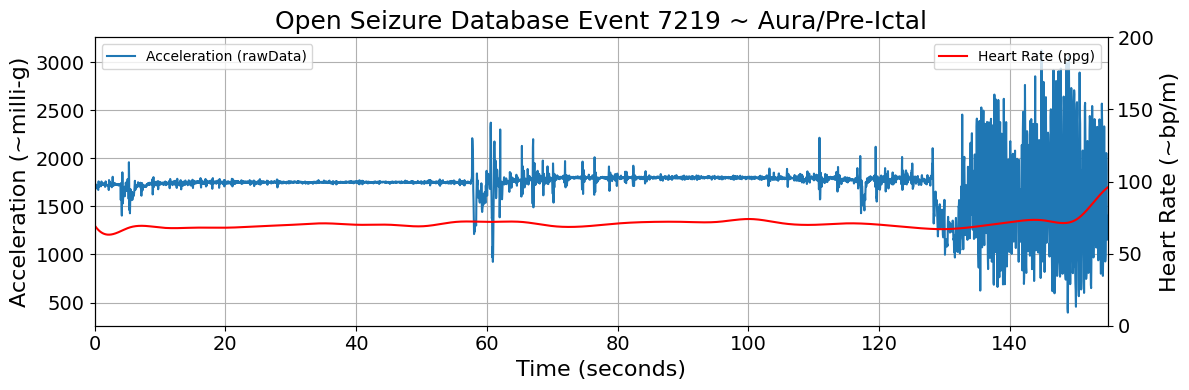

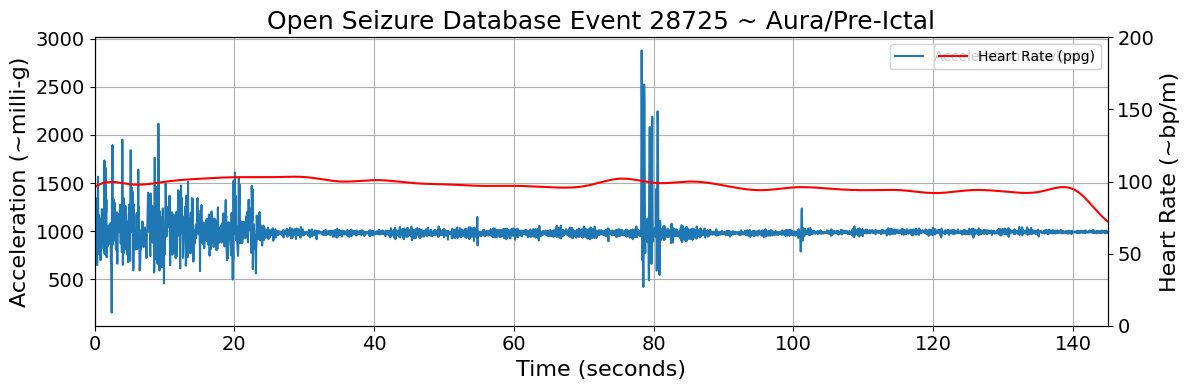

In [ ]:
#Filter sample data by subType
filtered_df = df[df['subType'] == 'Aura']

# Plot each eventId
for event_id, event_data in filtered_df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    subType = event_data["subType"].unique
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax2.set_ylim(0,200)
    ax1.grid(True)
    ax1.legend()
    ax2.legend()

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id} ~ Aura/Pre-Ictal", fontsize=18)

    # Adjust layout for spacing
    fig.tight_layout()

     # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Event_Types/Aura/event_{event_id}.png")

    # Show the plot
    plt.show()



##### 📂 **Subtype-Specific Visualization for Tonic-Clonic/Ictal Events**
<small>
This section focuses on visualizing and filtering events classified as `subType = 'Ictal'. It provides insights into the temporal patterns of these events by plotting key features.  

- **1️⃣ X-Axis**: Represents the time of the event in **5-second timesteps**.  
- **2️⃣ Y-Axis**: Displays the dataset's features:  
  - **📌 Acceleration** (`rawData`)  
  - **📌 Heart Rate** (`ppg`)  


The generated plots are automatically saved in the folder: **`Sample_Event_Types/Tonic-Clonic`**  
</small>

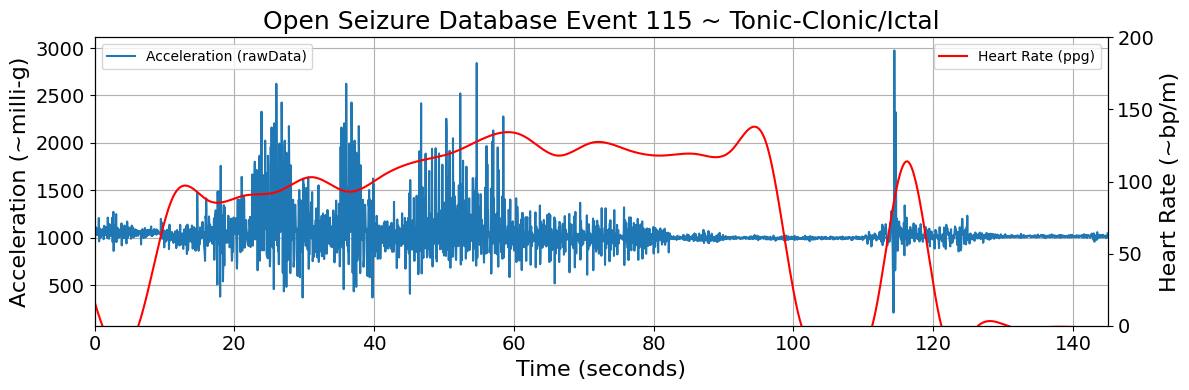

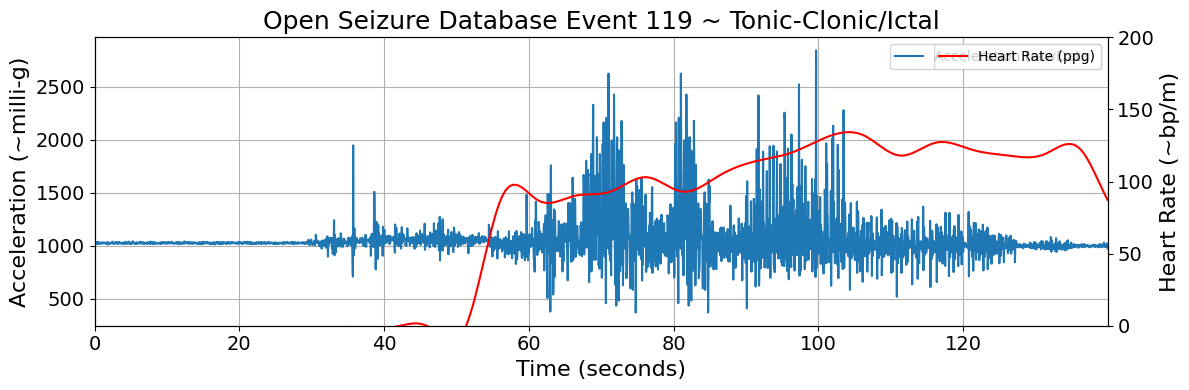

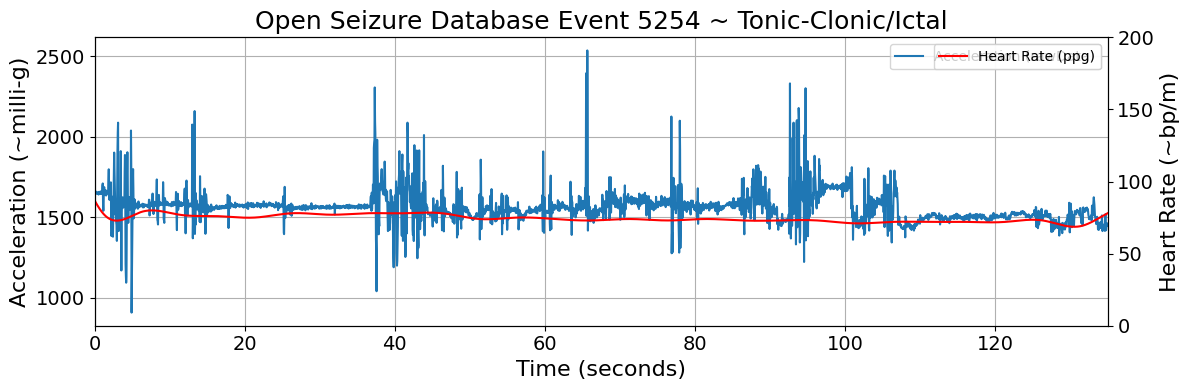

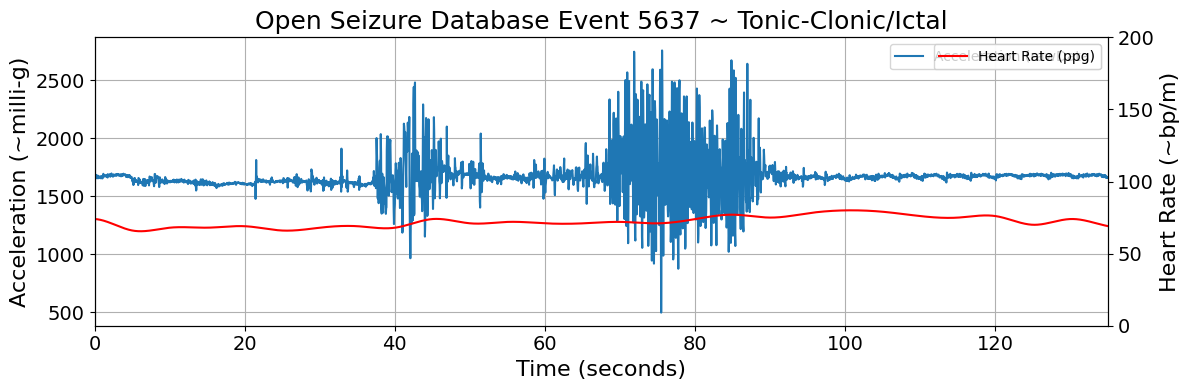

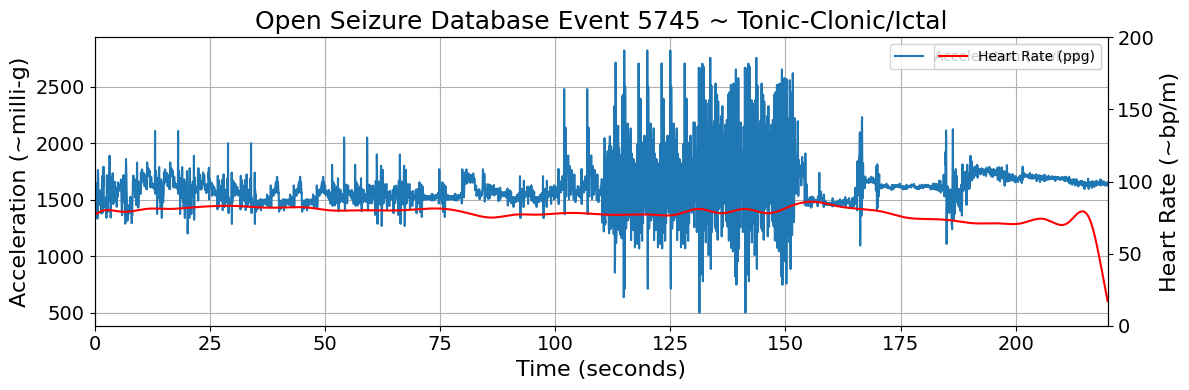

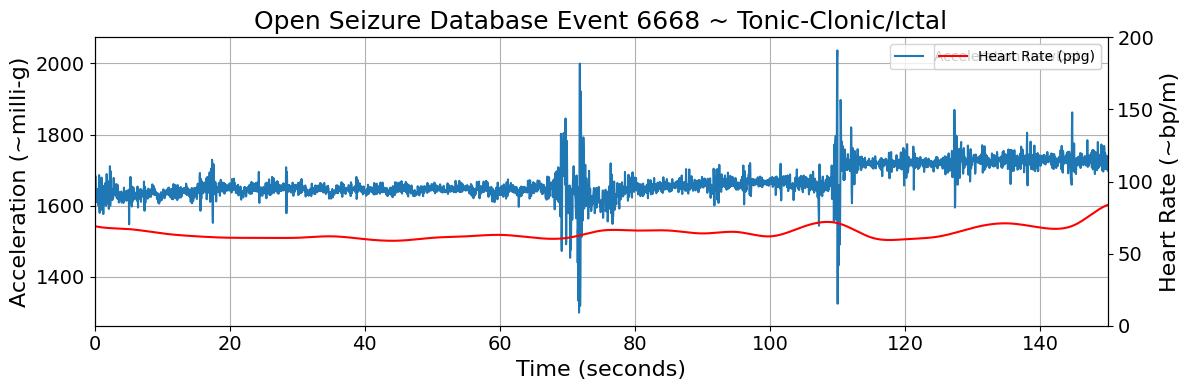

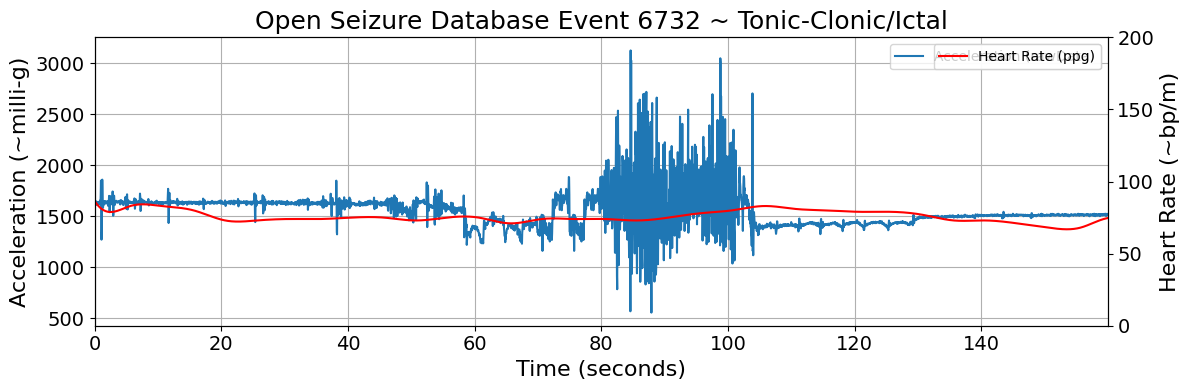

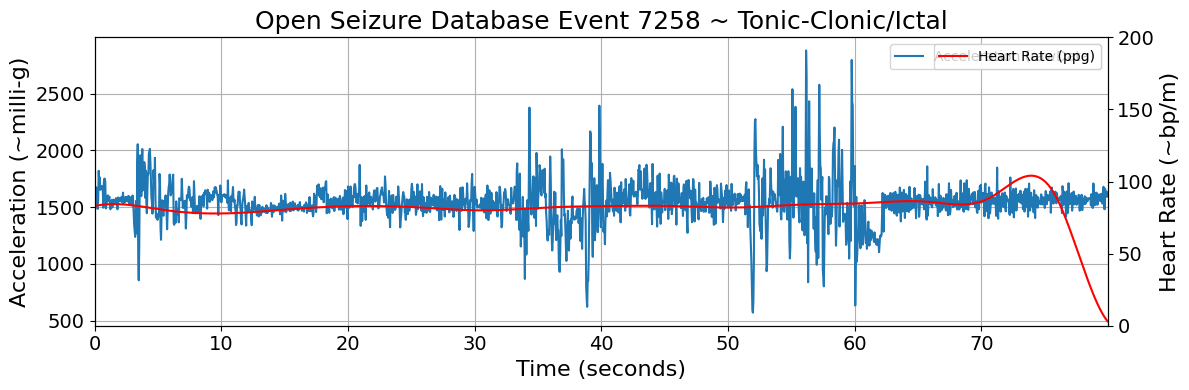

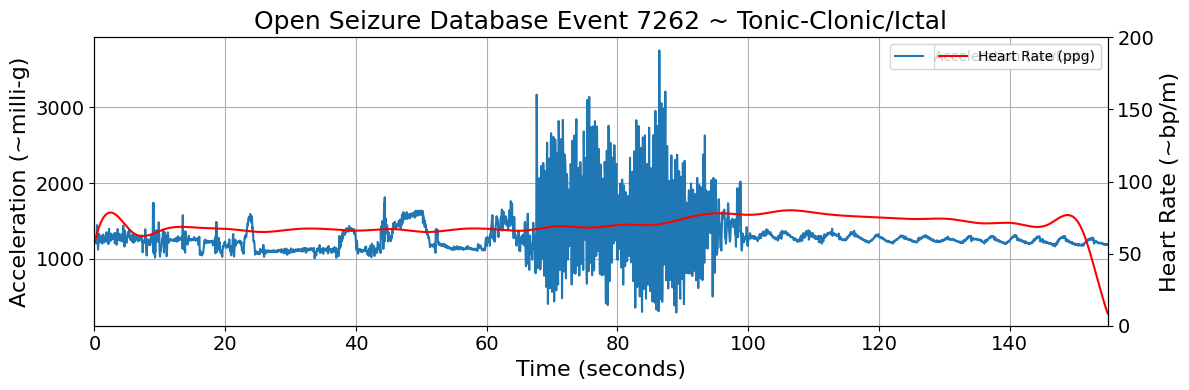

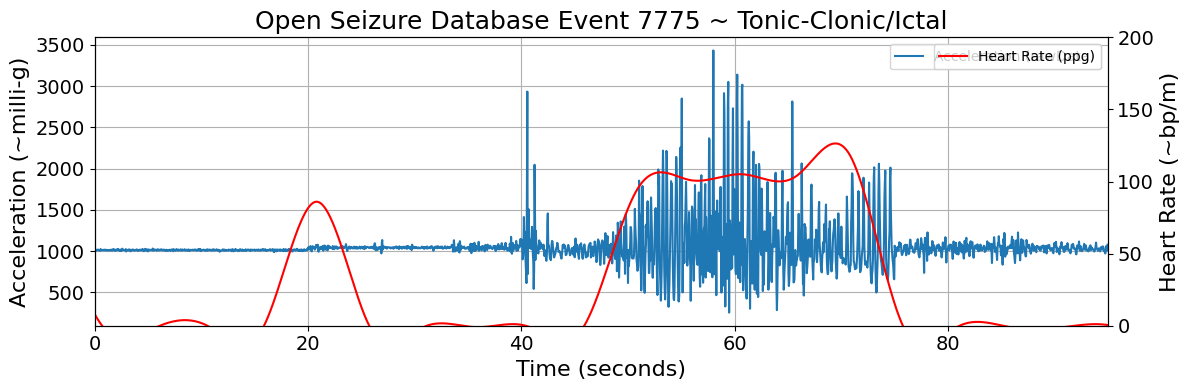

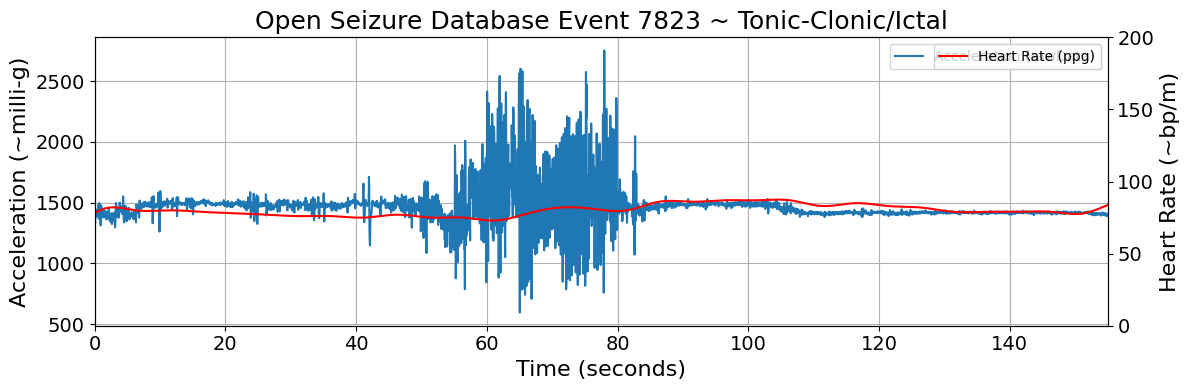

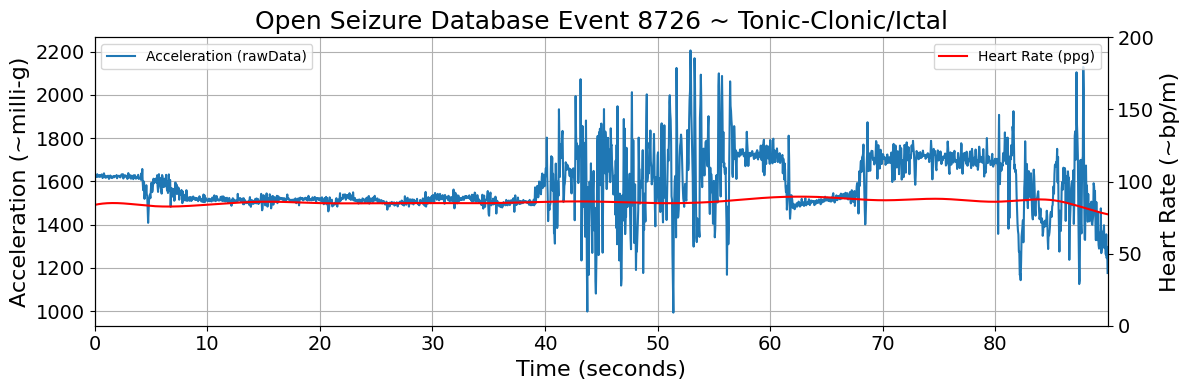

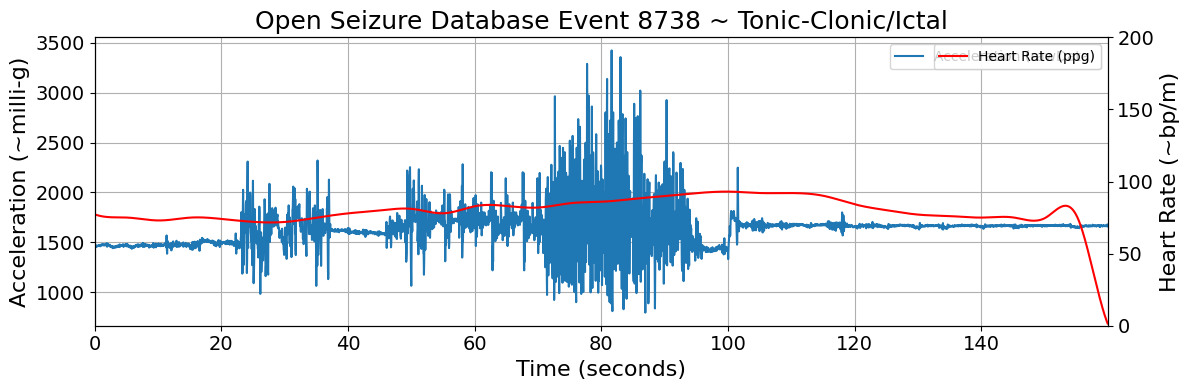

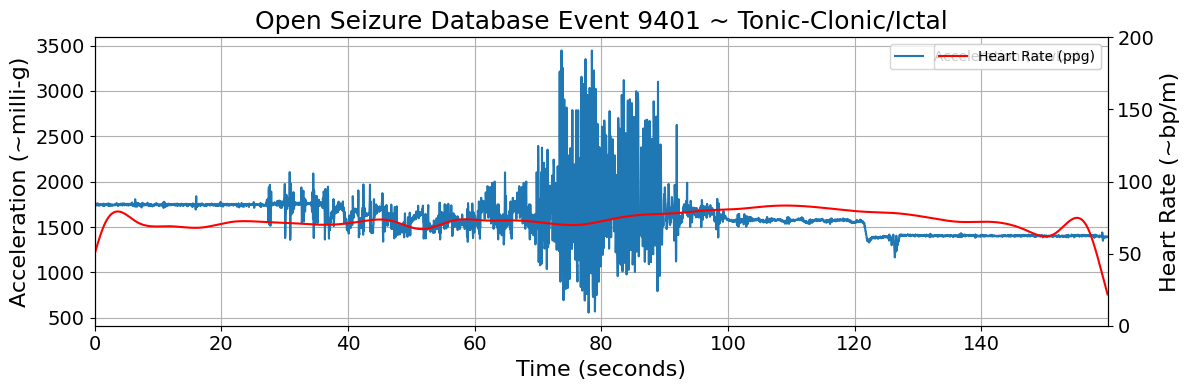

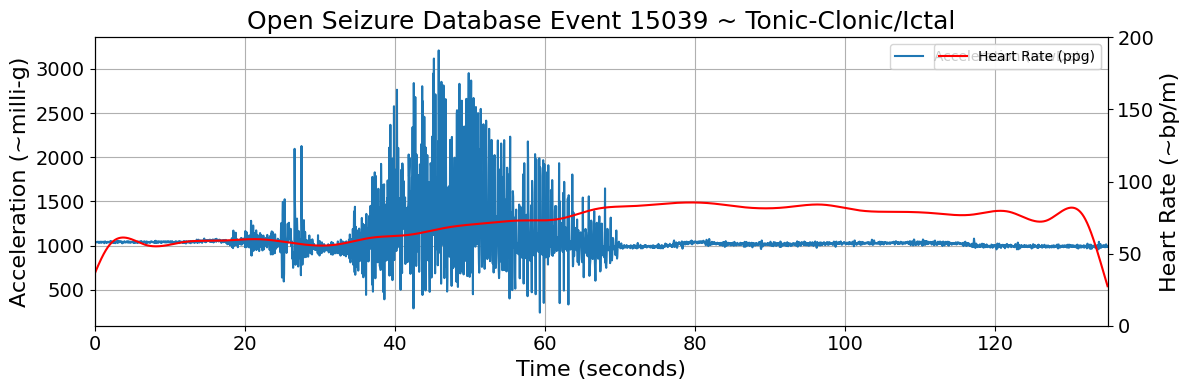

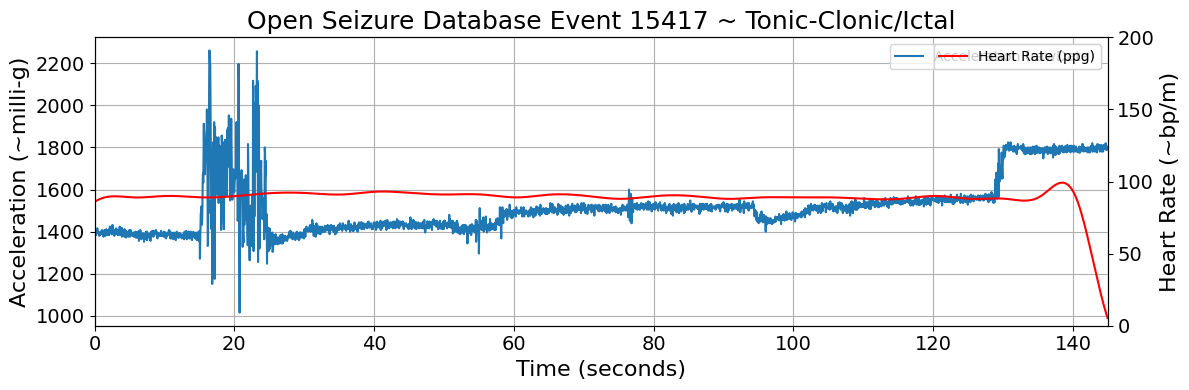

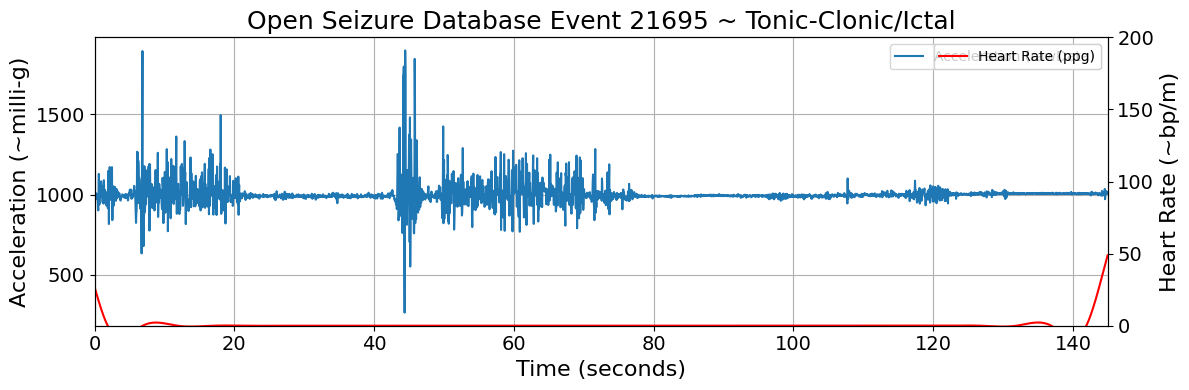

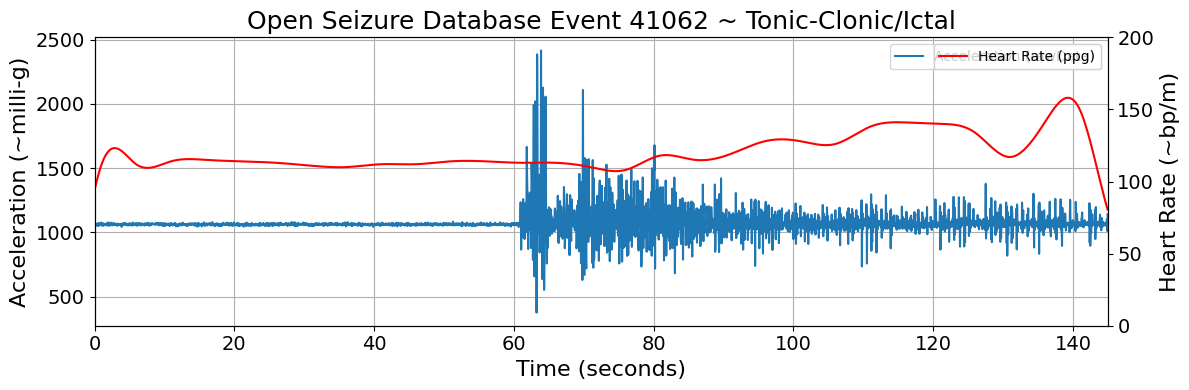

In [ ]:
#Filter sample data by subType
filtered_df = df[df['subType'] == 'Tonic-Clonic']

# Plot each eventId
for event_id, event_data in filtered_df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    subType = event_data["subType"].unique
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax2.set_ylim(0,200)
    ax1.grid(True)
    ax1.legend()
    ax2.legend()

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id} ~ Tonic-Clonic/Ictal", fontsize=18)

    # Adjust layout for spacing
    fig.tight_layout()

     # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Event_Types/Tonic-Clonic/event_{event_id}.png")

    # Show the plot
    plt.show()



##### 📂 **Subtype-Specific Visualization for Other Seizure/Unspecified Events**
<small>
This section focuses on visualizing and filtering events classified as `subType = 'Other'. It provides insights into the temporal patterns of these events by plotting key features.  

- **1️⃣ X-Axis**: Represents the time of the event in **5-second timesteps**.  
- **2️⃣ Y-Axis**: Displays the dataset's features:  
  - **📌 Acceleration** (`rawData`)  
  - **📌 Heart Rate** (`ppg`)  

The generated plots are automatically saved in the folder: **`Sample_Event_Types/Other_Seizures`**  
</small>

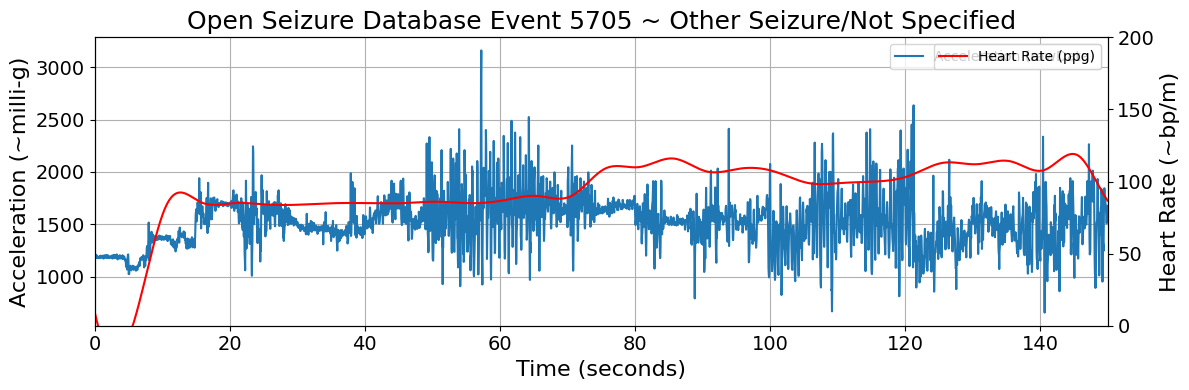

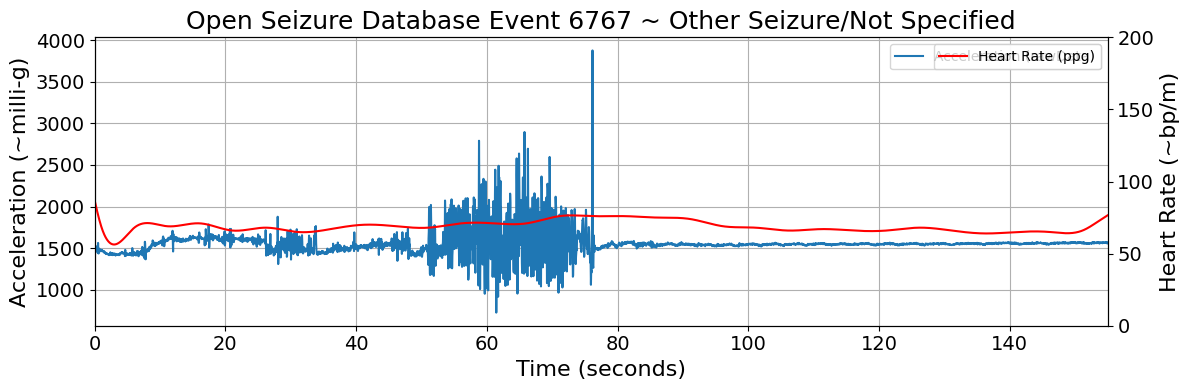

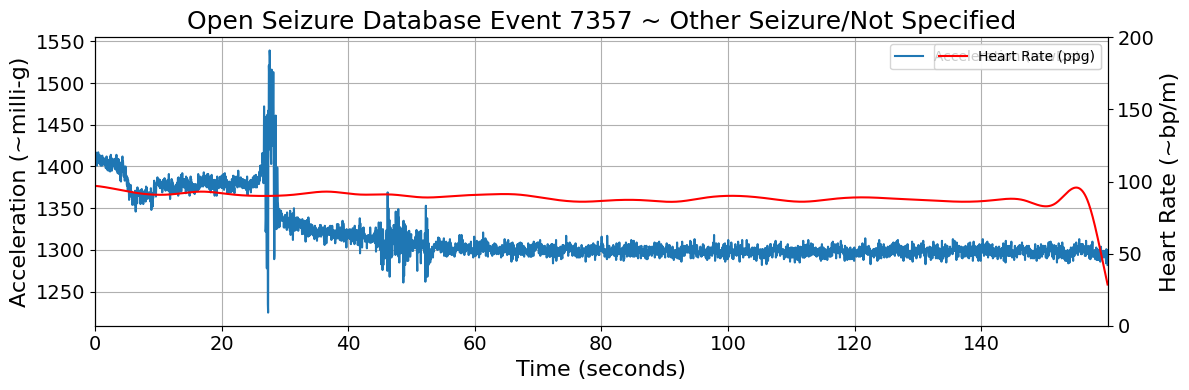

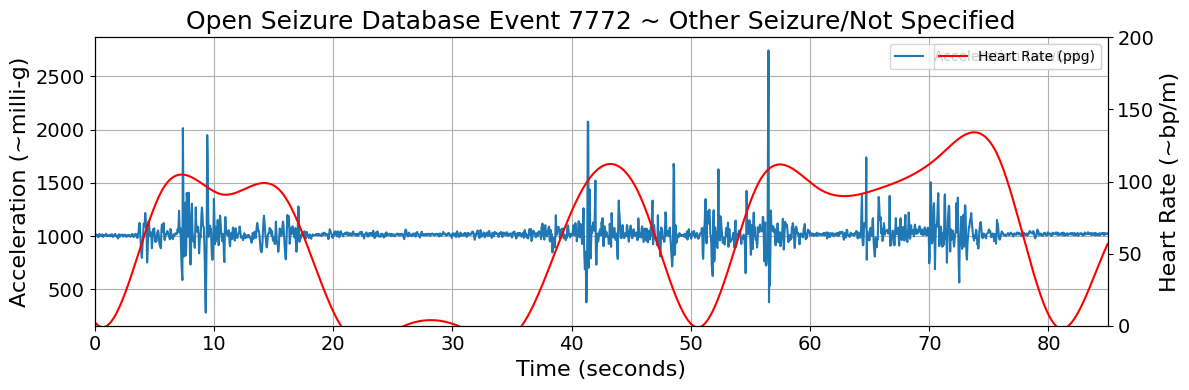

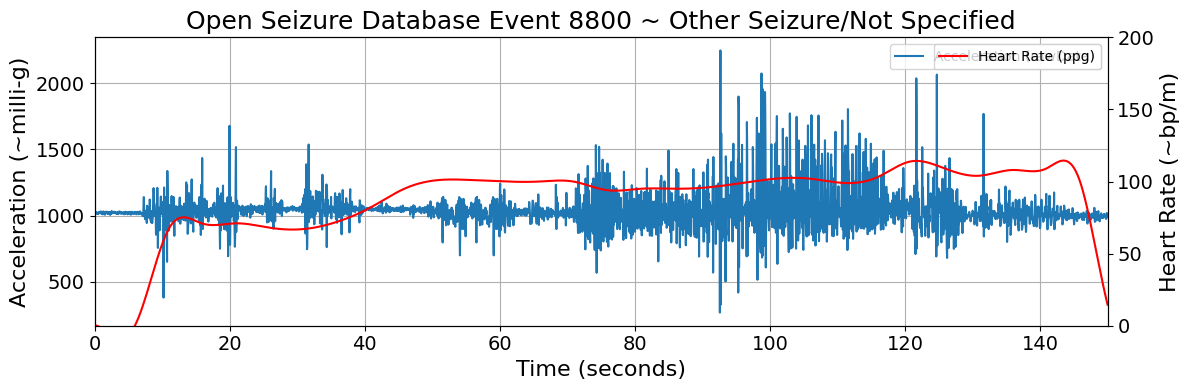

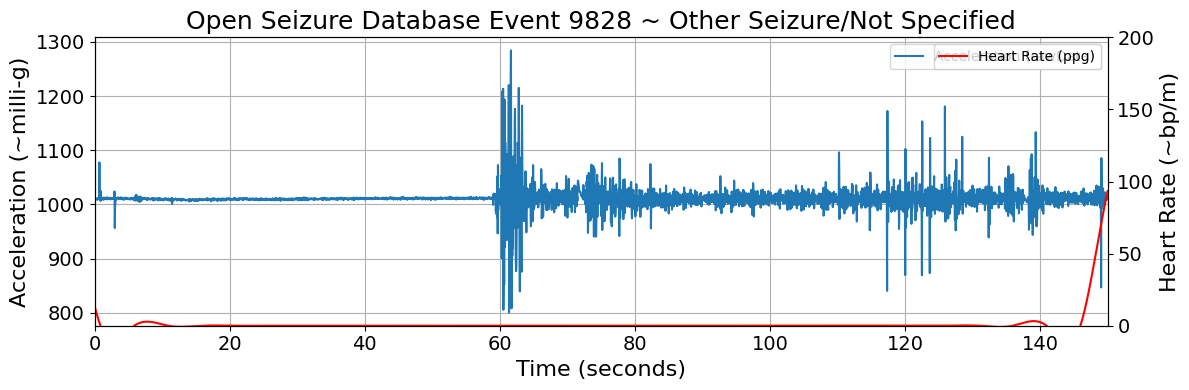

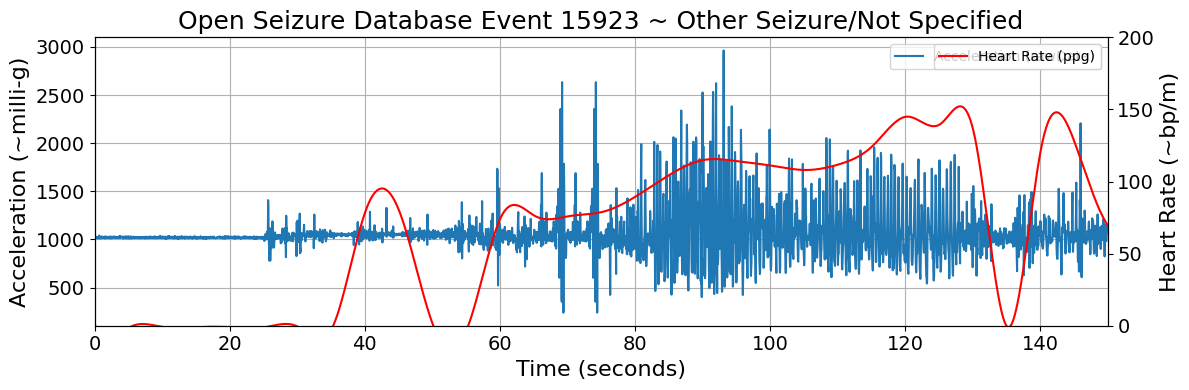

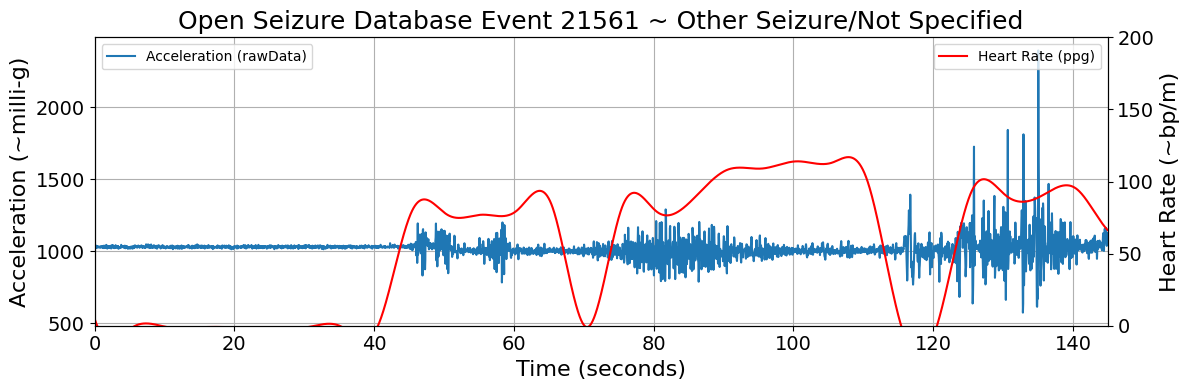

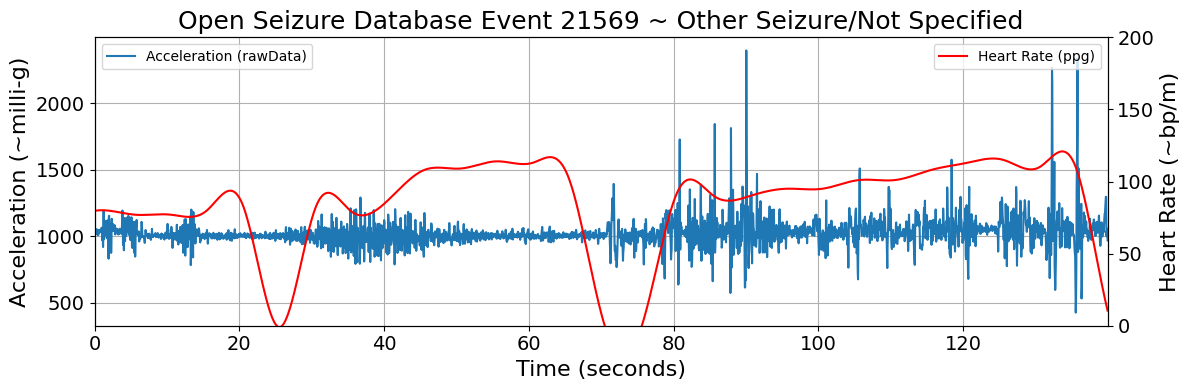

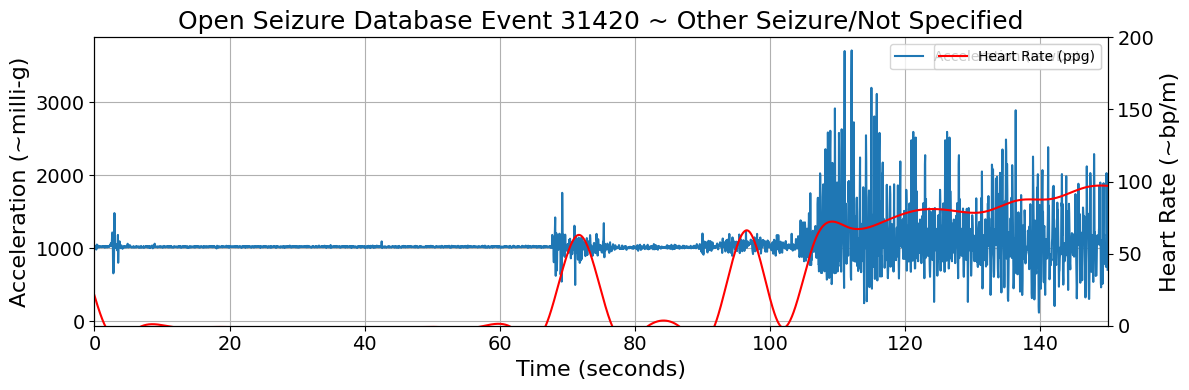

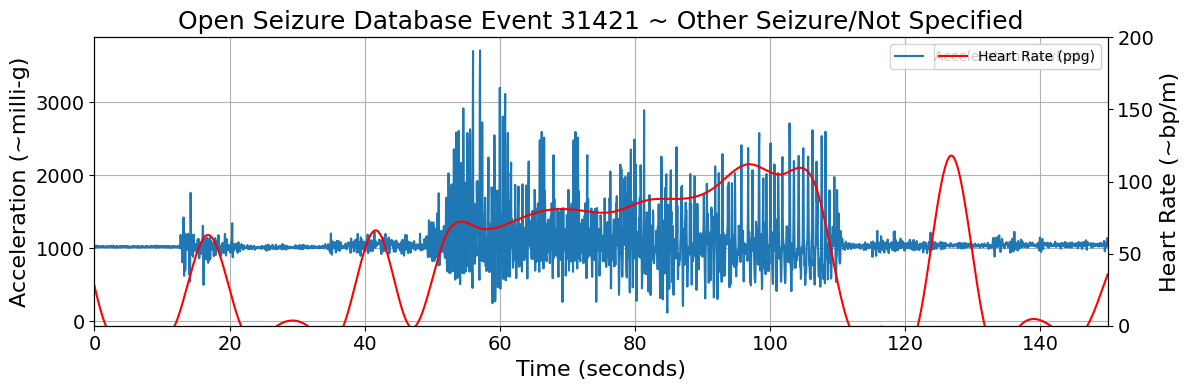

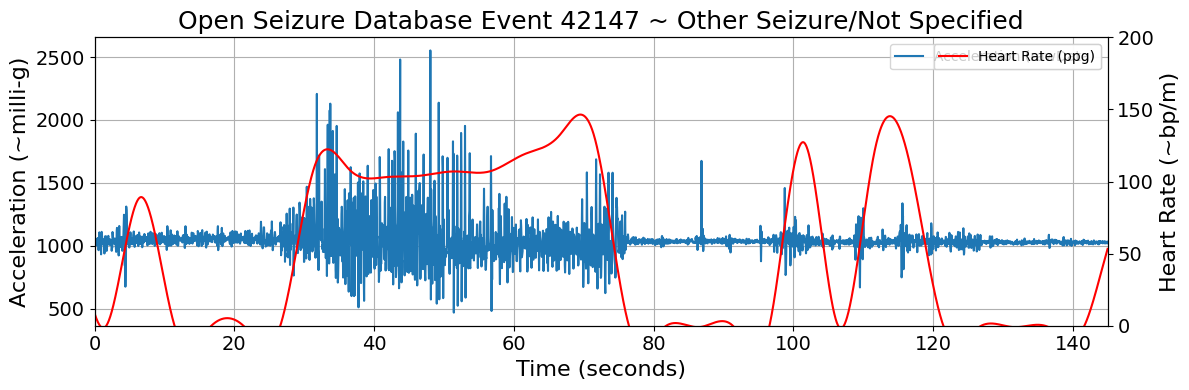

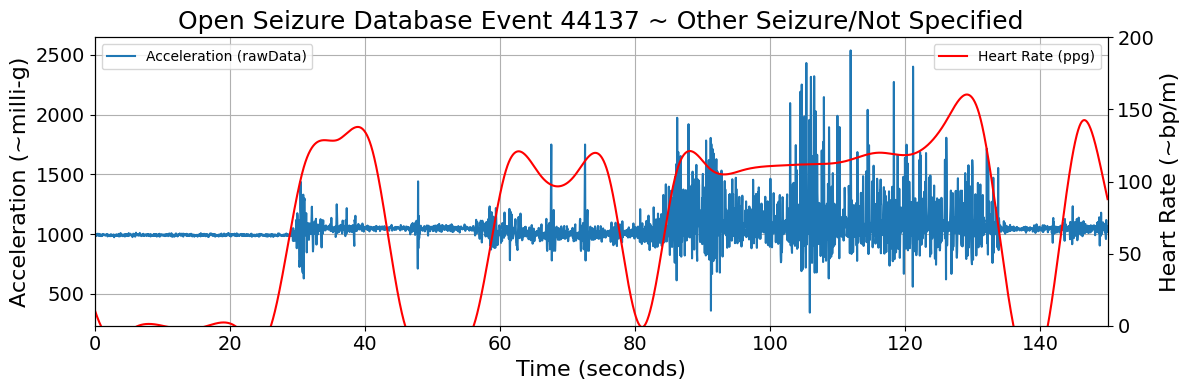

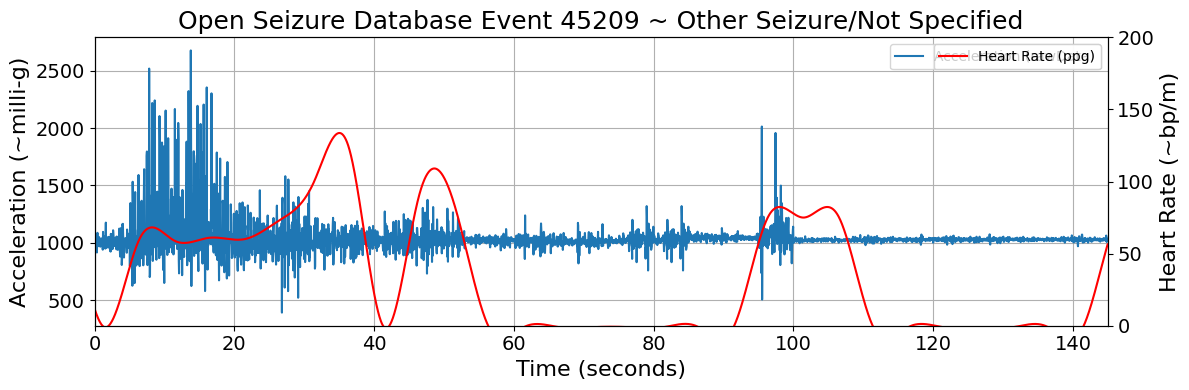

In [ ]:
#Filter sample data by subType
filtered_df = df[df['subType'] == 'Other']

# Plot each eventId
for event_id, event_data in filtered_df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    subType = event_data["subType"].unique
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax2.set_ylim(0,200)
    ax1.grid(True)
    ax1.legend()
    ax2.legend()

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id} ~ Other Seizure/Not Specified", fontsize=18)

    # Adjust layout for spacing
    fig.tight_layout()

     # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Event_Types/Other_Seizures/event_{event_id}.png")

    # Show the plot
    plt.show()



#### 📜 **Contact**  
<small>This notebook was created by **Jamie Pordoy**. Event data is sourced from the **Open Seizure Database (OSDB)**, with events expertly labeled and annotated by clinical experts as detailed in the IEEE *Journal of Biomedical and Health Informatics*. For any questions, issues, or feedback, feel free to reach out!  
</small>  